In [70]:
import os
import pandas as pd
import numpy as np
import re  # for extracting iteration numbers

# --- Configuration ---
path_to_scenarios = '/home/abhis/india_power/scenarios'
# scenario_names = ['iced_2050_cc_1','iced_2050_cc_2','iced_2050_cc_3'] # Example: Explicit list
# scenario_names = ['pier_mid_ra_2040_1','pier_mid_ra_2040_2','pier_mid_ra_2040_3'] # Example: Explicit list

scenario_names = ['capex_pier_prm_108_cc_90_hardovergen_2040_1','capex_pier_prm_108_cc_90_hardovergen_2040_2','capex_pier_prm_108_cc_90_hardovergen_2040_3',
                'capex_pier_prm_108_cc_90_hardovergen_2040_4','capex_pier_prm_108_cc_90_hardovergen_2040_5','capex_pier_prm_108_cc_90_hardovergen_2040_6',
                'capex_pier_prm_108_cc_90_hardovergen_2040_7','capex_pier_prm_108_cc_90_hardovergen_2040_8','capex_pier_prm_108_cc_90_hardovergen_2040_9',
                'capex_pier_prm_108_cc_90_hardovergen_2040_10','capex_pier_prm_108_cc_90_hardovergen_2040_11','capex_pier_prm_108_cc_90_hardovergen_2040_12',
                'capex_pier_prm_108_cc_90_hardovergen_2040_13','capex_pier_prm_108_cc_90_hardovergen_2040_14','capex_pier_prm_108_cc_90_hardovergen_2040_15',
                'capex_pier_prm_108_cc_90_hardovergen_2040_16','capex_pier_prm_108_cc_90_hardovergen_2040_17','capex_pier_prm_108_cc_90_hardovergen_2040_18'] # Example: Explicit list

# scenario_names = ['iced_mid_ra_2040_1','iced_mid_ra_2040_2','iced_mid_ra_2040_3']

print(f"Processing scenarios for project_timepoint & system_load_zone_timepoint: {scenario_names}")

selected_technologies = ['Solar']
print(f"Filtering for technologies: {selected_technologies if selected_technologies else 'All'}")

tech_groups = {
    'Wind':  ['Wind', 'Offshore'],
    'Solar': ['SolarPV_tilt', 'SolarPV_single', 'SolarPV_roof']
}

project_timepoint_dtypes = {
    'timepoint': 'int64',
    'load_zone': 'category',
    'technology': 'category',
    'power_mw': 'float32',
    'starting_energy_mwh': 'float32',
    'charge_mw': 'float32',
    'discharge_mw': 'float32',
    'net_power_mw': 'float32',
    'total_curtailment_mw': 'float32',
}
columns_to_read = list(project_timepoint_dtypes.keys())
if selected_technologies and 'technology' not in columns_to_read:
    columns_to_read.append('technology')
    print("Added 'technology' to columns_to_read for filtering.")
print(f"Reading project_timepoint columns: {columns_to_read}")

chunk_size = 100_000

all_project_timepoint_data = []
all_system_load_data      = []

# --- Traverse scenario folders ---
for scenario_name in scenario_names:
    scenario_path = os.path.join(path_to_scenarios, scenario_name)
    if not os.path.isdir(scenario_path):
        print(f"Warning: Scenario directory not found: {scenario_path}")
        continue

    for weather_folder in os.listdir(scenario_path):
        if not weather_folder.startswith('weather_iteration_'):
            continue
        wm = re.search(r'\d+', weather_folder)
        if not wm:
            continue
        weather_iteration = int(wm.group())
        weather_path      = os.path.join(scenario_path, weather_folder)

        for hydro_folder in os.listdir(weather_path):
            if not hydro_folder.startswith('hydro_iteration_'):
                continue
            hm = re.search(r'\d+', hydro_folder)
            if not hm:
                continue
            hydro_iteration = int(hm.group())
            hydro_path      = os.path.join(weather_path, hydro_folder)

            for avail_folder in os.listdir(hydro_path):
                if not avail_folder.startswith('availability_iteration_'):
                    continue
                am = re.search(r'\d+', avail_folder)
                if not am:
                    continue
                availability_iteration = int(am.group())
                avail_path             = os.path.join(hydro_path, avail_folder)
                results_path           = os.path.join(avail_path, 'results')

                # --- project_timepoint.csv ---
                proj_path = os.path.join(results_path, 'project_timepoint.csv')
                if os.path.exists(proj_path):
                    try:
                        reader = pd.read_csv(
                            proj_path,
                            dtype=project_timepoint_dtypes,
                            usecols=columns_to_read,
                            chunksize=chunk_size
                        )
                        for chunk in reader:
                            # add iteration metadata
                            chunk['weather_iteration']      = weather_iteration
                            chunk['hydro_iteration']        = hydro_iteration
                            chunk['availability_iteration'] = availability_iteration

                            # filter & collapse technologies
                            if selected_technologies and 'technology' in chunk:
                                expanded = []
                                for top in selected_technologies:
                                    expanded += tech_groups.get(top, [top])
                                chunk = chunk[chunk['technology'].isin(expanded)]
                                chunk['technology'] = chunk['technology'].map(
                                    lambda t: next((g for g,s in tech_groups.items() if t in s), t)
                                )
                            elif selected_technologies:
                                flag = 'warned_missing_tech_' + proj_path
                                if flag not in locals():
                                    print(f"Warning: no 'technology' in {proj_path}, cannot filter.")
                                    locals()[flag] = True

                            if not chunk.empty:
                                # downcast iterations
                                chunk = chunk.astype({
                                    'weather_iteration':      'int16',
                                    'hydro_iteration':        'int16',
                                    'availability_iteration': 'int16'
                                })
                                # reorder cols
                                it_cols = ['weather_iteration','hydro_iteration','availability_iteration']
                                orig   = [c for c in columns_to_read if c in chunk]
                                chunk  = chunk[it_cols + orig]
                                all_project_timepoint_data.append(chunk)
                        # cleanup warning flag
                        wf = 'warned_missing_tech_' + proj_path
                        if wf in locals():
                            del locals()[wf]
                    except Exception as e:
                        print(f"Error processing {proj_path}: {e}")
                else:
                    print(f"Warning: project_timepoint.csv not found in {results_path}")

                # --- system_load_zone_timepoint.csv ---
                sys_path = os.path.join(results_path, 'system_load_zone_timepoint.csv')
                if os.path.exists(sys_path):
                    try:
                        df_sys = pd.read_csv(sys_path)
                        df_sys['scenario_name']         = scenario_name
                        df_sys['weather_iteration']     = weather_iteration
                        df_sys['hydro_iteration']       = hydro_iteration
                        df_sys['availability_iteration']= availability_iteration

                        it_cols = ['scenario_name','weather_iteration','hydro_iteration','availability_iteration']
                        others  = [c for c in df_sys.columns if c not in it_cols]
                        df_sys  = df_sys[it_cols + others]

                        all_system_load_data.append(df_sys)
                    except Exception as e:
                        print(f"Error reading {sys_path}: {e}")
                else:
                    print(f"Warning: system_load_zone_timepoint.csv not found in {results_path}")

# --- Concatenate project_timepoint data ---
if all_project_timepoint_data:
    final_project_timepoint_df = pd.concat(all_project_timepoint_data, ignore_index=True)
    print("Combined project_timepoint DataFrame created.")
    print(final_project_timepoint_df.head())
    print(final_project_timepoint_df.info(memory_usage='deep'))
else:
    print("No project_timepoint data found.")

# --- Concatenate system_load data ---
if all_system_load_data:
    final_system_load_df = pd.concat(all_system_load_data, ignore_index=True)
    print("Combined system_load_zone_timepoint DataFrame created.")
    print(final_system_load_df.head())
else:
    print("No system_load_zone_timepoint data found.")

# --- Add timestamp to project_timepoint ---
if 'final_project_timepoint_df' in locals() and not final_project_timepoint_df.empty:
    try:
        dfp = final_project_timepoint_df
        dfp['timepoint_str'] = dfp['timepoint'].astype(str)
        dfp['date_str']      = dfp['timepoint_str'].str[:8]
        dfp['hour_str']      = dfp['timepoint_str'].str[8:]
        dfp['hour_int']      = dfp['hour_str'].astype(int) - 1

        dfp['timestamp'] = (
            pd.to_datetime(dfp['date_str'], format='%Y%m%d')
            + pd.to_timedelta(dfp['hour_int'], unit='h')
        )
        dfp.drop(columns=['timepoint_str','date_str','hour_str','hour_int'], inplace=True)

        cols = list(dfp.columns)
        cols.insert(0, cols.pop(cols.index('timestamp')))
        final_project_timepoint_df = dfp[cols]
        print("Timestamp added to project_timepoint DataFrame.")
    except Exception as e:
        print(f"Error timestamping project_timepoint: {e}")

# --- Calculate static_load and add timestamp to system_load ---
if 'final_system_load_df' in locals() and not final_system_load_df.empty:
    # static_load_mw
    req = ['total_power_mw','net_imports_mw','unserved_energy_mw','overgeneration_mw','total_curtailment_mw']
    ok  = True
    for c in req:
        if c in final_system_load_df:
            final_system_load_df[c] = pd.to_numeric(final_system_load_df[c], errors='coerce')
        else:
            print(f"Missing column {c} in system load DataFrame.")
            ok = False
    if ok:
        final_system_load_df['static_load_mw'] = (
            final_system_load_df['total_power_mw'].fillna(0)
          + final_system_load_df['net_imports_mw'].fillna(0)
          + final_system_load_df['unserved_energy_mw'].fillna(0)
          - final_system_load_df['overgeneration_mw'].fillna(0)
        )
        print("static_load_mw calculated.")

    try:
        dfs = final_system_load_df
        dfs['timepoint_str'] = dfs['timepoint'].astype(str)
        dfs['date_str']      = dfs['timepoint_str'].str[:8]
        dfs['hour_str']      = dfs['timepoint_str'].str[8:]
        dfs['hour_int']      = dfs['hour_str'].astype(int) - 1

        dfs['timestamp'] = (
            pd.to_datetime(dfs['date_str'], format='%Y%m%d')
            + pd.to_timedelta(dfs['hour_int'], unit='h')
        )
        dfs.drop(columns=['timepoint_str','date_str','hour_str','hour_int'], inplace=True)

        cols = list(dfs.columns)
        cols.insert(0, cols.pop(cols.index('timestamp')))
        final_system_load_df = dfs[cols]
        print("Timestamp added to system_load DataFrame.")
    except Exception as e:
        print(f"Error timestamping system load DataFrame: {e}")

    # drop scenario_name if present
    if 'scenario_name' in final_system_load_df.columns:
        final_system_load_df.drop(columns=['scenario_name'], inplace=True)
        print("Dropped 'scenario_name' from system load DataFrame.")


Processing scenarios for project_timepoint & system_load_zone_timepoint: ['capex_pier_prm_108_cc_90_hardovergen_2040_1', 'capex_pier_prm_108_cc_90_hardovergen_2040_2', 'capex_pier_prm_108_cc_90_hardovergen_2040_3', 'capex_pier_prm_108_cc_90_hardovergen_2040_4', 'capex_pier_prm_108_cc_90_hardovergen_2040_5', 'capex_pier_prm_108_cc_90_hardovergen_2040_6', 'capex_pier_prm_108_cc_90_hardovergen_2040_7', 'capex_pier_prm_108_cc_90_hardovergen_2040_8', 'capex_pier_prm_108_cc_90_hardovergen_2040_9', 'capex_pier_prm_108_cc_90_hardovergen_2040_10', 'capex_pier_prm_108_cc_90_hardovergen_2040_11', 'capex_pier_prm_108_cc_90_hardovergen_2040_12', 'capex_pier_prm_108_cc_90_hardovergen_2040_13', 'capex_pier_prm_108_cc_90_hardovergen_2040_14', 'capex_pier_prm_108_cc_90_hardovergen_2040_15', 'capex_pier_prm_108_cc_90_hardovergen_2040_16', 'capex_pier_prm_108_cc_90_hardovergen_2040_17', 'capex_pier_prm_108_cc_90_hardovergen_2040_18']
Filtering for technologies: ['Solar']
Reading project_timepoint columns

/tmp/ipykernel_457137/4246817929.py:240: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_system_load_df.drop(columns=['scenario_name'], inplace=True)


In [72]:
import pandas as pd

# --- User options ---
selected_technologies = ['Wind','solar']   # or [] for all
selected_load_zones  = ['national']         # or e.g. ['AP','Gujarat'], or [] for all

print(f"Filtering technologies: {selected_technologies or 'All'}")
print(f"Filtering load_zones:   {selected_load_zones or 'All'}")

# --- Ensure source DataFrames exist ---
if not (
    'final_project_timepoint_df' in locals()
    and 'final_system_load_df' in locals()
):
    raise ValueError("Missing final_project_timepoint_df or final_system_load_df")

# --- 1) Prepare project‐timepoint DataFrame ---
proj = final_project_timepoint_df.copy()

# a) Filter by technology if requested
if selected_technologies:
    proj = proj[proj['technology'].isin(selected_technologies)]

# b) Handle load_zone selection or national‐aggregation
if selected_load_zones and selected_load_zones == ['national']:
    # aggregate across all zones into a single 'national' zone
    proj = (
        proj
        .groupby(
            ['timestamp','weather_iteration','hydro_iteration','availability_iteration','technology'],
            as_index=False
        )['power_mw']
        .sum()
    )
    proj['load_zone'] = 'national'
elif selected_load_zones:
    proj = proj[proj['load_zone'].isin(selected_load_zones)]
# else: keep all zones as-is

if proj.empty:
    print("Warning: No project_timepoint rows after filtering/aggregation")

# --- 2) Prepare system_load_zone_timepoint DataFrame ---
sys = final_system_load_df.copy()

# a) Filter by zone if not national
if selected_load_zones and selected_load_zones != ['national']:
    sys = sys[sys['load_zone'].isin(selected_load_zones)]

# b) If national, aggregate across zones
if selected_load_zones and selected_load_zones == ['national']:
    agg_cols = ['static_load_mw','unserved_energy_mw','overgeneration_mw']
    sys = (
        sys
        .groupby(
            ['timestamp','weather_iteration','hydro_iteration','availability_iteration'],
            as_index=False
        )[agg_cols]
        .sum()
    )
    sys['load_zone'] = 'national'
# else: sys keeps its load_zone column

if sys.empty:
    print("Warning: No system_load rows after filtering/aggregation")

# --- 3) Merge ---
join_keys = [
    'timestamp',
    'weather_iteration',
    'hydro_iteration',
    'availability_iteration',
    'load_zone'
]
merged_df = pd.merge(
    proj,
    sys,
    on=join_keys,
    how='left',
    validate='many_to_one'
)

# --- 4) Rename tech column to indicate combined Wind/Solar if desired ---
if selected_technologies:
    merged_df.loc[:, 'technology'] = 'wind_solar'

# --- 5) Inspect result ---
print("Merged DataFrame head:")
print(merged_df.head())
print("\nMerged DataFrame info:")
merged_df.info(memory_usage='deep')


Filtering technologies: ['Wind', 'solar']
Filtering load_zones:   ['national']
Merged DataFrame head:
Empty DataFrame
Columns: [timestamp, weather_iteration, hydro_iteration, availability_iteration, technology, power_mw, load_zone, static_load_mw, unserved_energy_mw, overgeneration_mw]
Index: []

Merged DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   timestamp               0 non-null      datetime64[ns]
 1   weather_iteration       0 non-null      int16         
 2   hydro_iteration         0 non-null      int16         
 3   availability_iteration  0 non-null      int16         
 4   technology              0 non-null      object        
 5   power_mw                0 non-null      float32       
 6   load_zone               0 non-null      object        
 7   static_load_mw          0 non-null      f

In [ ]:
# Function to filter or aggregate data based on load_zone selection,
# while preserving iteration columns
def filter_or_aggregate_by_load_zone(df, selected_load_zone):
    if selected_load_zone.lower() == 'national':
        # Aggregate all load zones but keep iteration columns
        grouped = df.groupby([
            'timestamp',
            'weather_iteration',
            'hydro_iteration',
            'availability_iteration',
            'technology'
        ], as_index=False).agg({
            'power_mw': 'sum',
            'starting_energy_mwh': 'sum',
            'charge_mw': 'sum',
            'discharge_mw': 'sum',
            'net_power_mw': 'sum',
            'total_curtailment_mw': 'sum'
        })
        grouped['load_zone'] = 'national'
        return grouped
    else:
        # Just filter for the selected load_zone (case-insensitive)
        return df[df['load_zone'].str.lower() == selected_load_zone.lower()]

# Example usage
selected_load_zone = 'national'  
filtered_or_aggregated_df = filter_or_aggregate_by_load_zone(final_project_timepoint_df, selected_load_zone)

print(filtered_or_aggregated_df.head())


   timestamp  weather_iteration  hydro_iteration  availability_iteration  \
0 2040-04-01                  1                1                       1   
1 2040-04-01                  2                2                       2   
2 2040-04-01                  3                3                       3   
3 2040-04-01                  4                4                       4   
4 2040-04-01                  5                5                       5   

  technology       power_mw  starting_energy_mwh  charge_mw  discharge_mw  \
0       Wind  243712.562500                  0.0        0.0           0.0   
1       Wind  134750.500000                  0.0        0.0           0.0   
2       Wind  179913.203125                  0.0        0.0           0.0   
3       Wind  259604.671875                  0.0        0.0           0.0   
4       Wind  219876.781250                  0.0        0.0           0.0   

   net_power_mw  total_curtailment_mw load_zone  
0           0.0              0

/tmp/ipykernel_457137/1427703916.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


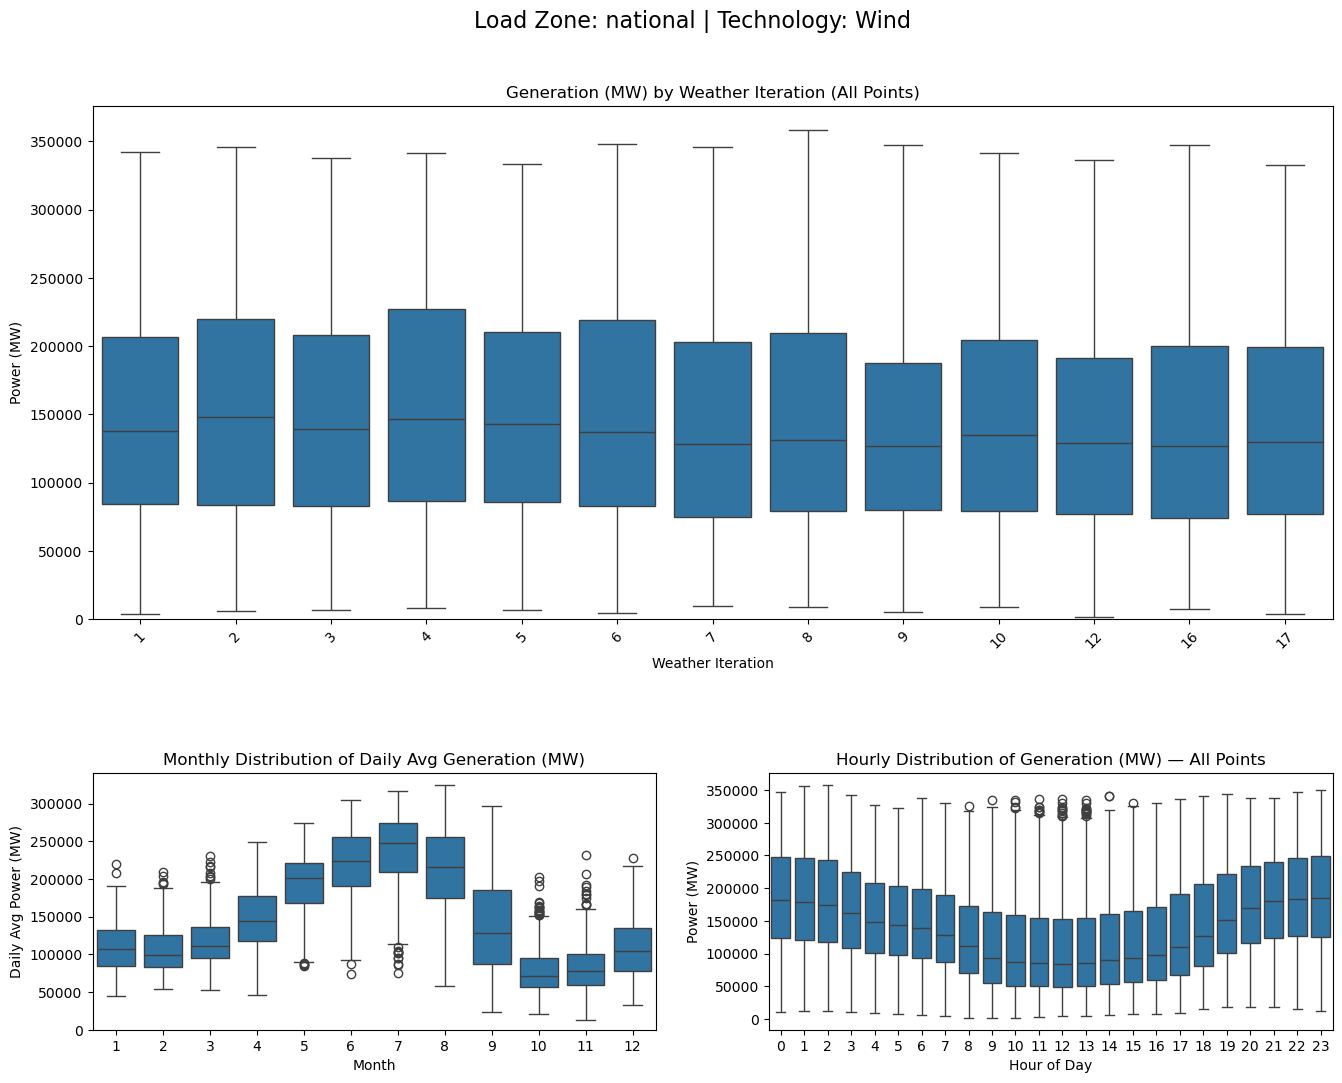

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

# 1) Prepare your DataFrame
df = filtered_or_aggregated_df.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date']      = df['timestamp'].dt.date
df['hour']      = df['timestamp'].dt.hour

# 2) Compute daily average load
daily_avg_df = (
    df
    .groupby(['weather_iteration', 'date'], as_index=False)['power_mw']
    .mean()
)
# extract month from the date
daily_avg_df['month'] = pd.to_datetime(daily_avg_df['date']).dt.month

# 3) Build a simple suptitle
zones = df['load_zone'].unique()
techs = df['technology'].unique()
suptitle = (
    f"Load Zone: {zones[0] if len(zones)==1 else 'Multiple Zones'} | "
    f"Technology: {', '.join(techs) if len(techs)>0 else 'All Technologies'}"
)

# 4) Create a 2×2 grid: top plot spans both columns, bottom row for monthly & hourly
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, height_ratios=[2, 1], hspace=0.4)

ax0 = fig.add_subplot(gs[0, :])  # Row 0 spans both columns
ax1 = fig.add_subplot(gs[1, 0])  # Row 1, Col 0
ax2 = fig.add_subplot(gs[1, 1])  # Row 1, Col 1

fig.suptitle(suptitle, y=0.96, fontsize=16)

# Top: Raw Power by Weather Iteration
sns.boxplot(data=df, x='weather_iteration', y='power_mw', ax=ax0)
ax0.set_title('Generation (MW) by Weather Iteration (All Points)')
ax0.set_xlabel('Weather Iteration')
ax0.set_ylabel('Power (MW)')
ax0.tick_params(axis='x', rotation=45)
# force Y-axis start at zero
ax0.set_ylim(bottom=0)

# Bottom-left: Monthly Distribution of Daily Avg Power
sns.boxplot(data=daily_avg_df, x='month', y='power_mw', ax=ax1)
ax1.set_title('Monthly Distribution of Daily Avg Generation (MW)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Daily Avg Power (MW)')
# force Y-axis start at zero
ax1.set_ylim(bottom=0)

# Bottom-right: Raw Hourly Distribution (all data points)
sns.boxplot(data=df, x='hour', y='power_mw', ax=ax2)
ax2.set_title('Hourly Distribution of Generation (MW) — All Points')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Power (MW)')
ax2.set_xticks(range(24))

# 5) Final layout adjustment
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


In [ ]:
if 'merged_df' in locals() and not merged_df.empty:
    if 'static_load_mw' in merged_df.columns and 'power_mw' in merged_df.columns:
        merged_df['net_demand'] = merged_df['static_load_mw'] - merged_df['power_mw']
        print("Column 'net_demand' added to merged_df.")
        print(merged_df[['static_load_mw', 'power_mw', 'net_demand']].head())
    else:
        print("Error: 'static_load_mw' or 'power_mw' column not found in merged_df.")
else:
    print("Error: merged_df is not defined or is empty.")


Column 'net_demand' added to merged_df.
   static_load_mw       power_mw     net_demand
0   356639.894731  243712.562500  112927.332231
1   344471.731626  134750.500000  209721.231626
2   333142.308974  179913.203125  153229.105849
3   346976.546262  259604.671875   87371.874387
4   347954.250561  219876.781250  128077.469311


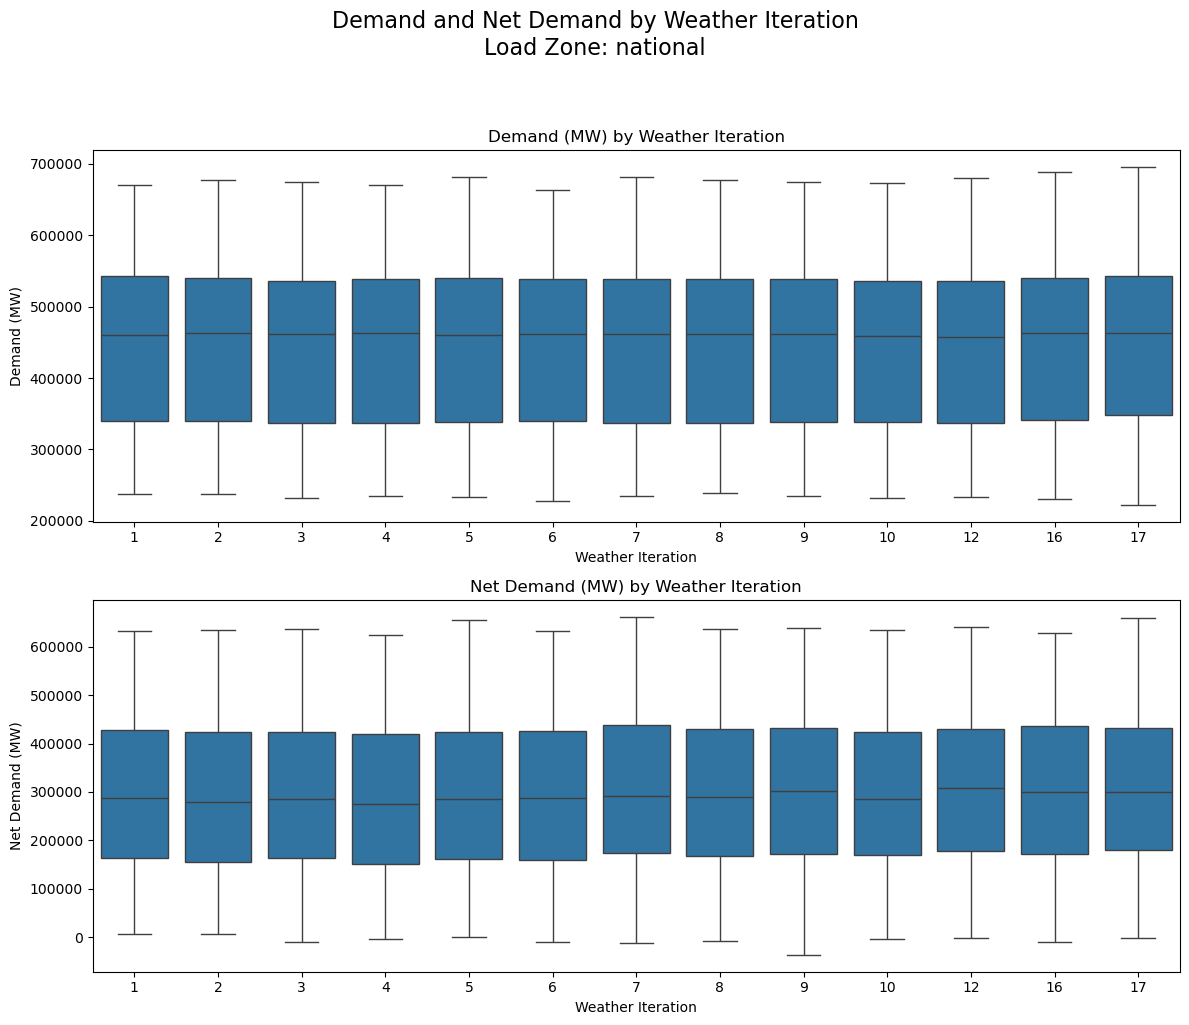

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# 1) Verify merged_df exists and has the needed columns
if 'merged_df' not in locals() or merged_df.empty:
    print("Error: merged_df is not defined or is empty. Please run previous cells.")
else:
    required_cols = ['weather_iteration', 'static_load_mw', 'net_demand', 'load_zone', 'technology']
    missing_cols = [col for col in required_cols if col not in merged_df.columns]
    if missing_cols:
        print(f"Error: Missing required columns in merged_df: {missing_cols}")
    else:
        # 2) Create a figure and subplots (2 rows, 1 column)
        fig, axes = plt.subplots(2, 1, figsize=(12, 10))
        
        # 3) Construct suptitle
        zones = merged_df['load_zone'].unique()
        techs = merged_df['technology'].unique()
        suptitle_text = (
            f"Demand and Net Demand by Weather Iteration\n"
            f"Load Zone: {zones[0] if len(zones)==1 else 'Multiple Zones'}"
        )
        fig.suptitle(suptitle_text, fontsize=16, y=1.02)

        # 4) Plot 1: static_load_mw vs weather_iteration
        sns.boxplot(data=merged_df, x='weather_iteration', y='static_load_mw', ax=axes[0])
        axes[0].set_title('Demand (MW) by Weather Iteration')
        axes[0].set_xlabel('Weather Iteration')
        axes[0].set_ylabel('Demand (MW)')

        # 5) Plot 2: net_demand vs weather_iteration
        sns.boxplot(data=merged_df, x='weather_iteration', y='net_demand', ax=axes[1])
        axes[1].set_title('Net Demand (MW) by Weather Iteration')
        axes[1].set_xlabel('Weather Iteration')
        axes[1].set_ylabel('Net Demand (MW)')

        # 6) Adjust layout and show plot
        plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust rect to make space for suptitle
        plt.show()

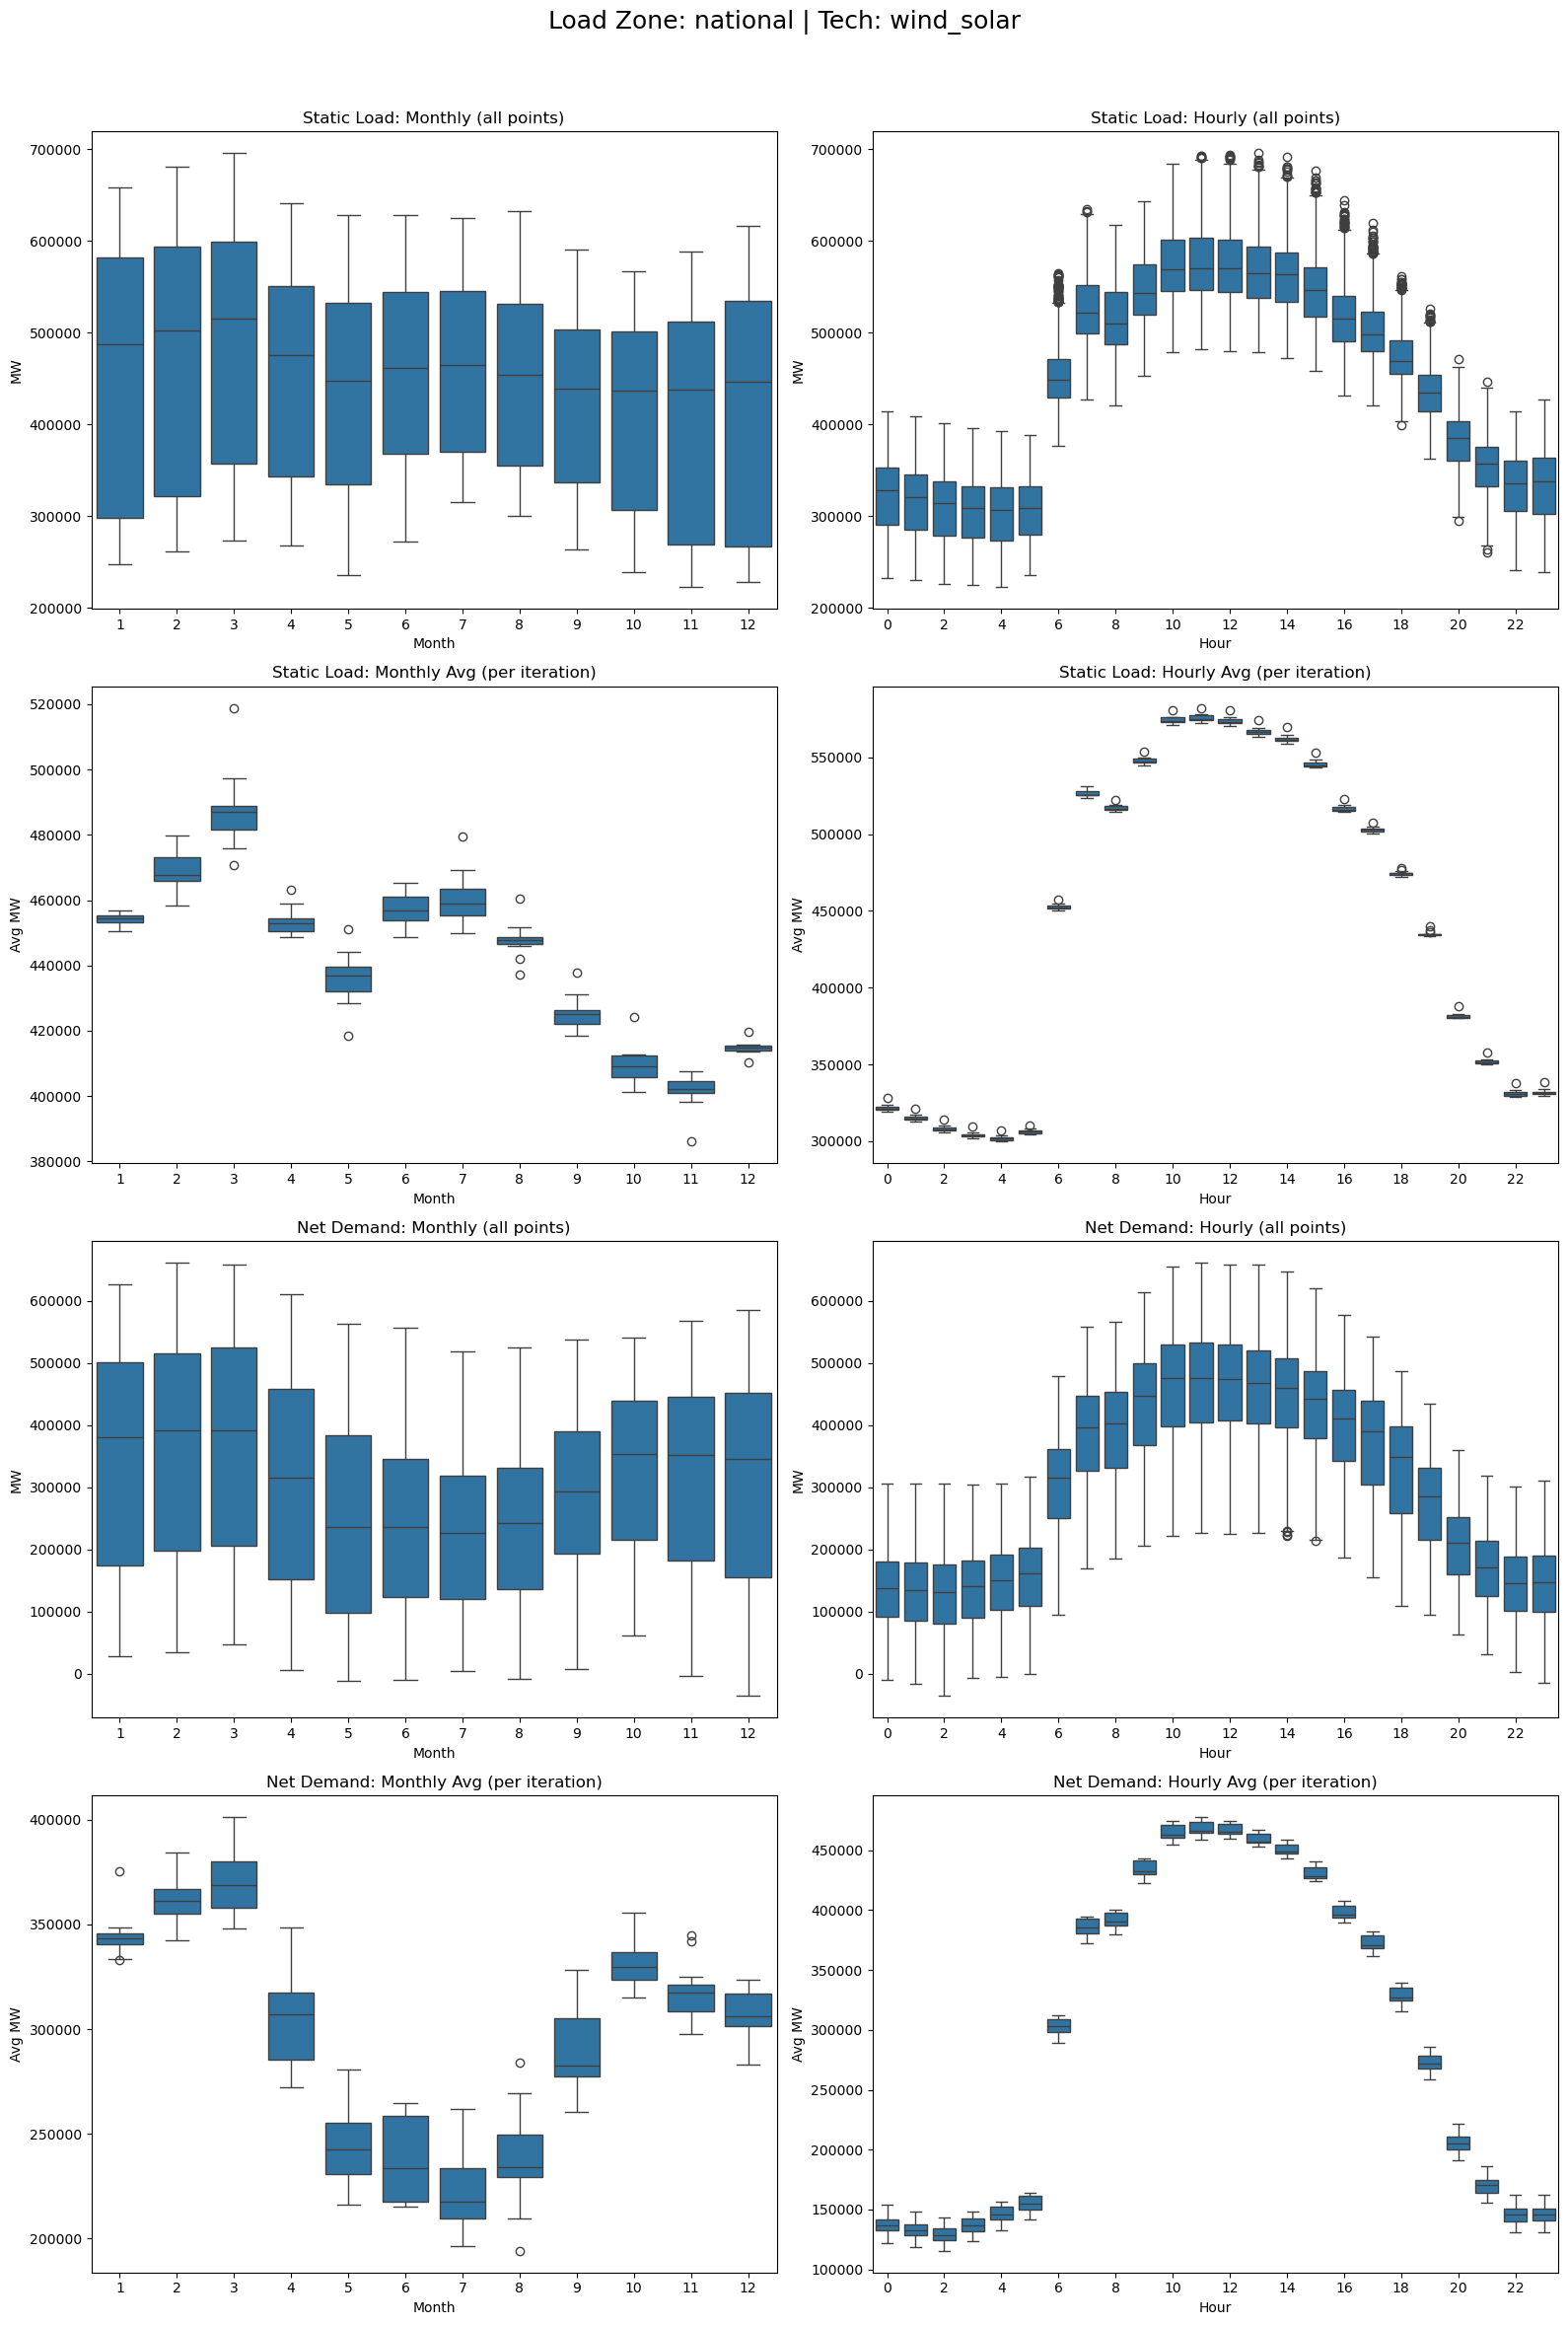

In [ ]:
# --- 1) Compute net_demand so the column exists ---
# Assumes merged_df has both 'static_load_mw' (demand) and 'power_mw' (renewables)
merged_df['net_demand'] = merged_df['static_load_mw'] - merged_df['power_mw']

# --- 2) Now do the 4×2 grid of boxplots for static_load_mw & net_demand vs month/hour ---
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare
plot_df = merged_df.copy()
plot_df['month'] = plot_df['timestamp'].dt.month
plot_df['hour']  = plot_df['timestamp'].dt.hour

# Averages per weather_iteration
if 'weather_iteration' in plot_df.columns:
    m_avg_static = plot_df.groupby(['weather_iteration','month'], as_index=False)['static_load_mw'].mean()
    h_avg_static = plot_df.groupby(['weather_iteration','hour'],  as_index=False)['static_load_mw'].mean()
    m_avg_net    = plot_df.groupby(['weather_iteration','month'], as_index=False)['net_demand'].mean()
    h_avg_net    = plot_df.groupby(['weather_iteration','hour'],  as_index=False)['net_demand'].mean()
else:
    m_avg_static = plot_df.groupby(['month'], as_index=False)['static_load_mw'].mean()
    h_avg_static = plot_df.groupby(['hour'],  as_index=False)['static_load_mw'].mean()
    m_avg_net    = plot_df.groupby(['month'], as_index=False)['net_demand'].mean()
    h_avg_net    = plot_df.groupby(['hour'],  as_index=False)['net_demand'].mean()

# Suptitle
zones = plot_df['load_zone'].unique()
techs = plot_df['technology'].unique()
suptitle = (
    f"Load Zone: {zones[0] if len(zones)==1 else 'Multiple Zones'} | "
    f"Tech: {', '.join(techs)}"
)

# 4×2 grid
fig, axes = plt.subplots(4, 2, figsize=(16, 24))
fig.suptitle(suptitle, y=0.98, fontsize=18)

# Row 0: Static raw
sns.boxplot(data=plot_df, x='month', y='static_load_mw', ax=axes[0,0])
axes[0,0].set(title='Static Load: Monthly (all points)', xlabel='Month', ylabel='MW')
sns.boxplot(data=plot_df, x='hour', y='static_load_mw', ax=axes[0,1])
axes[0,1].set(title='Static Load: Hourly (all points)', xlabel='Hour', ylabel='MW')
axes[0,1].set_xticks(range(0,24,2))

# Row 1: Static averaged
sns.boxplot(data=m_avg_static, x='month', y='static_load_mw', ax=axes[1,0])
axes[1,0].set(title='Static Load: Monthly Avg (per iteration)', xlabel='Month', ylabel='Avg MW')
sns.boxplot(data=h_avg_static, x='hour', y='static_load_mw', ax=axes[1,1])
axes[1,1].set(title='Static Load: Hourly Avg (per iteration)', xlabel='Hour', ylabel='Avg MW')
axes[1,1].set_xticks(range(0,24,2))

# Row 2: Net raw
sns.boxplot(data=plot_df, x='month', y='net_demand', ax=axes[2,0])
axes[2,0].set(title='Net Demand: Monthly (all points)', xlabel='Month', ylabel='MW')
sns.boxplot(data=plot_df, x='hour', y='net_demand', ax=axes[2,1])
axes[2,1].set(title='Net Demand: Hourly (all points)', xlabel='Hour', ylabel='MW')
axes[2,1].set_xticks(range(0,24,2))

# Row 3: Net averaged
sns.boxplot(data=m_avg_net, x='month', y='net_demand', ax=axes[3,0])
axes[3,0].set(title='Net Demand: Monthly Avg (per iteration)', xlabel='Month', ylabel='Avg MW')
sns.boxplot(data=h_avg_net, x='hour', y='net_demand', ax=axes[3,1])
axes[3,1].set(title='Net Demand: Hourly Avg (per iteration)', xlabel='Hour', ylabel='Avg MW')
axes[3,1].set_xticks(range(0,24,2))

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


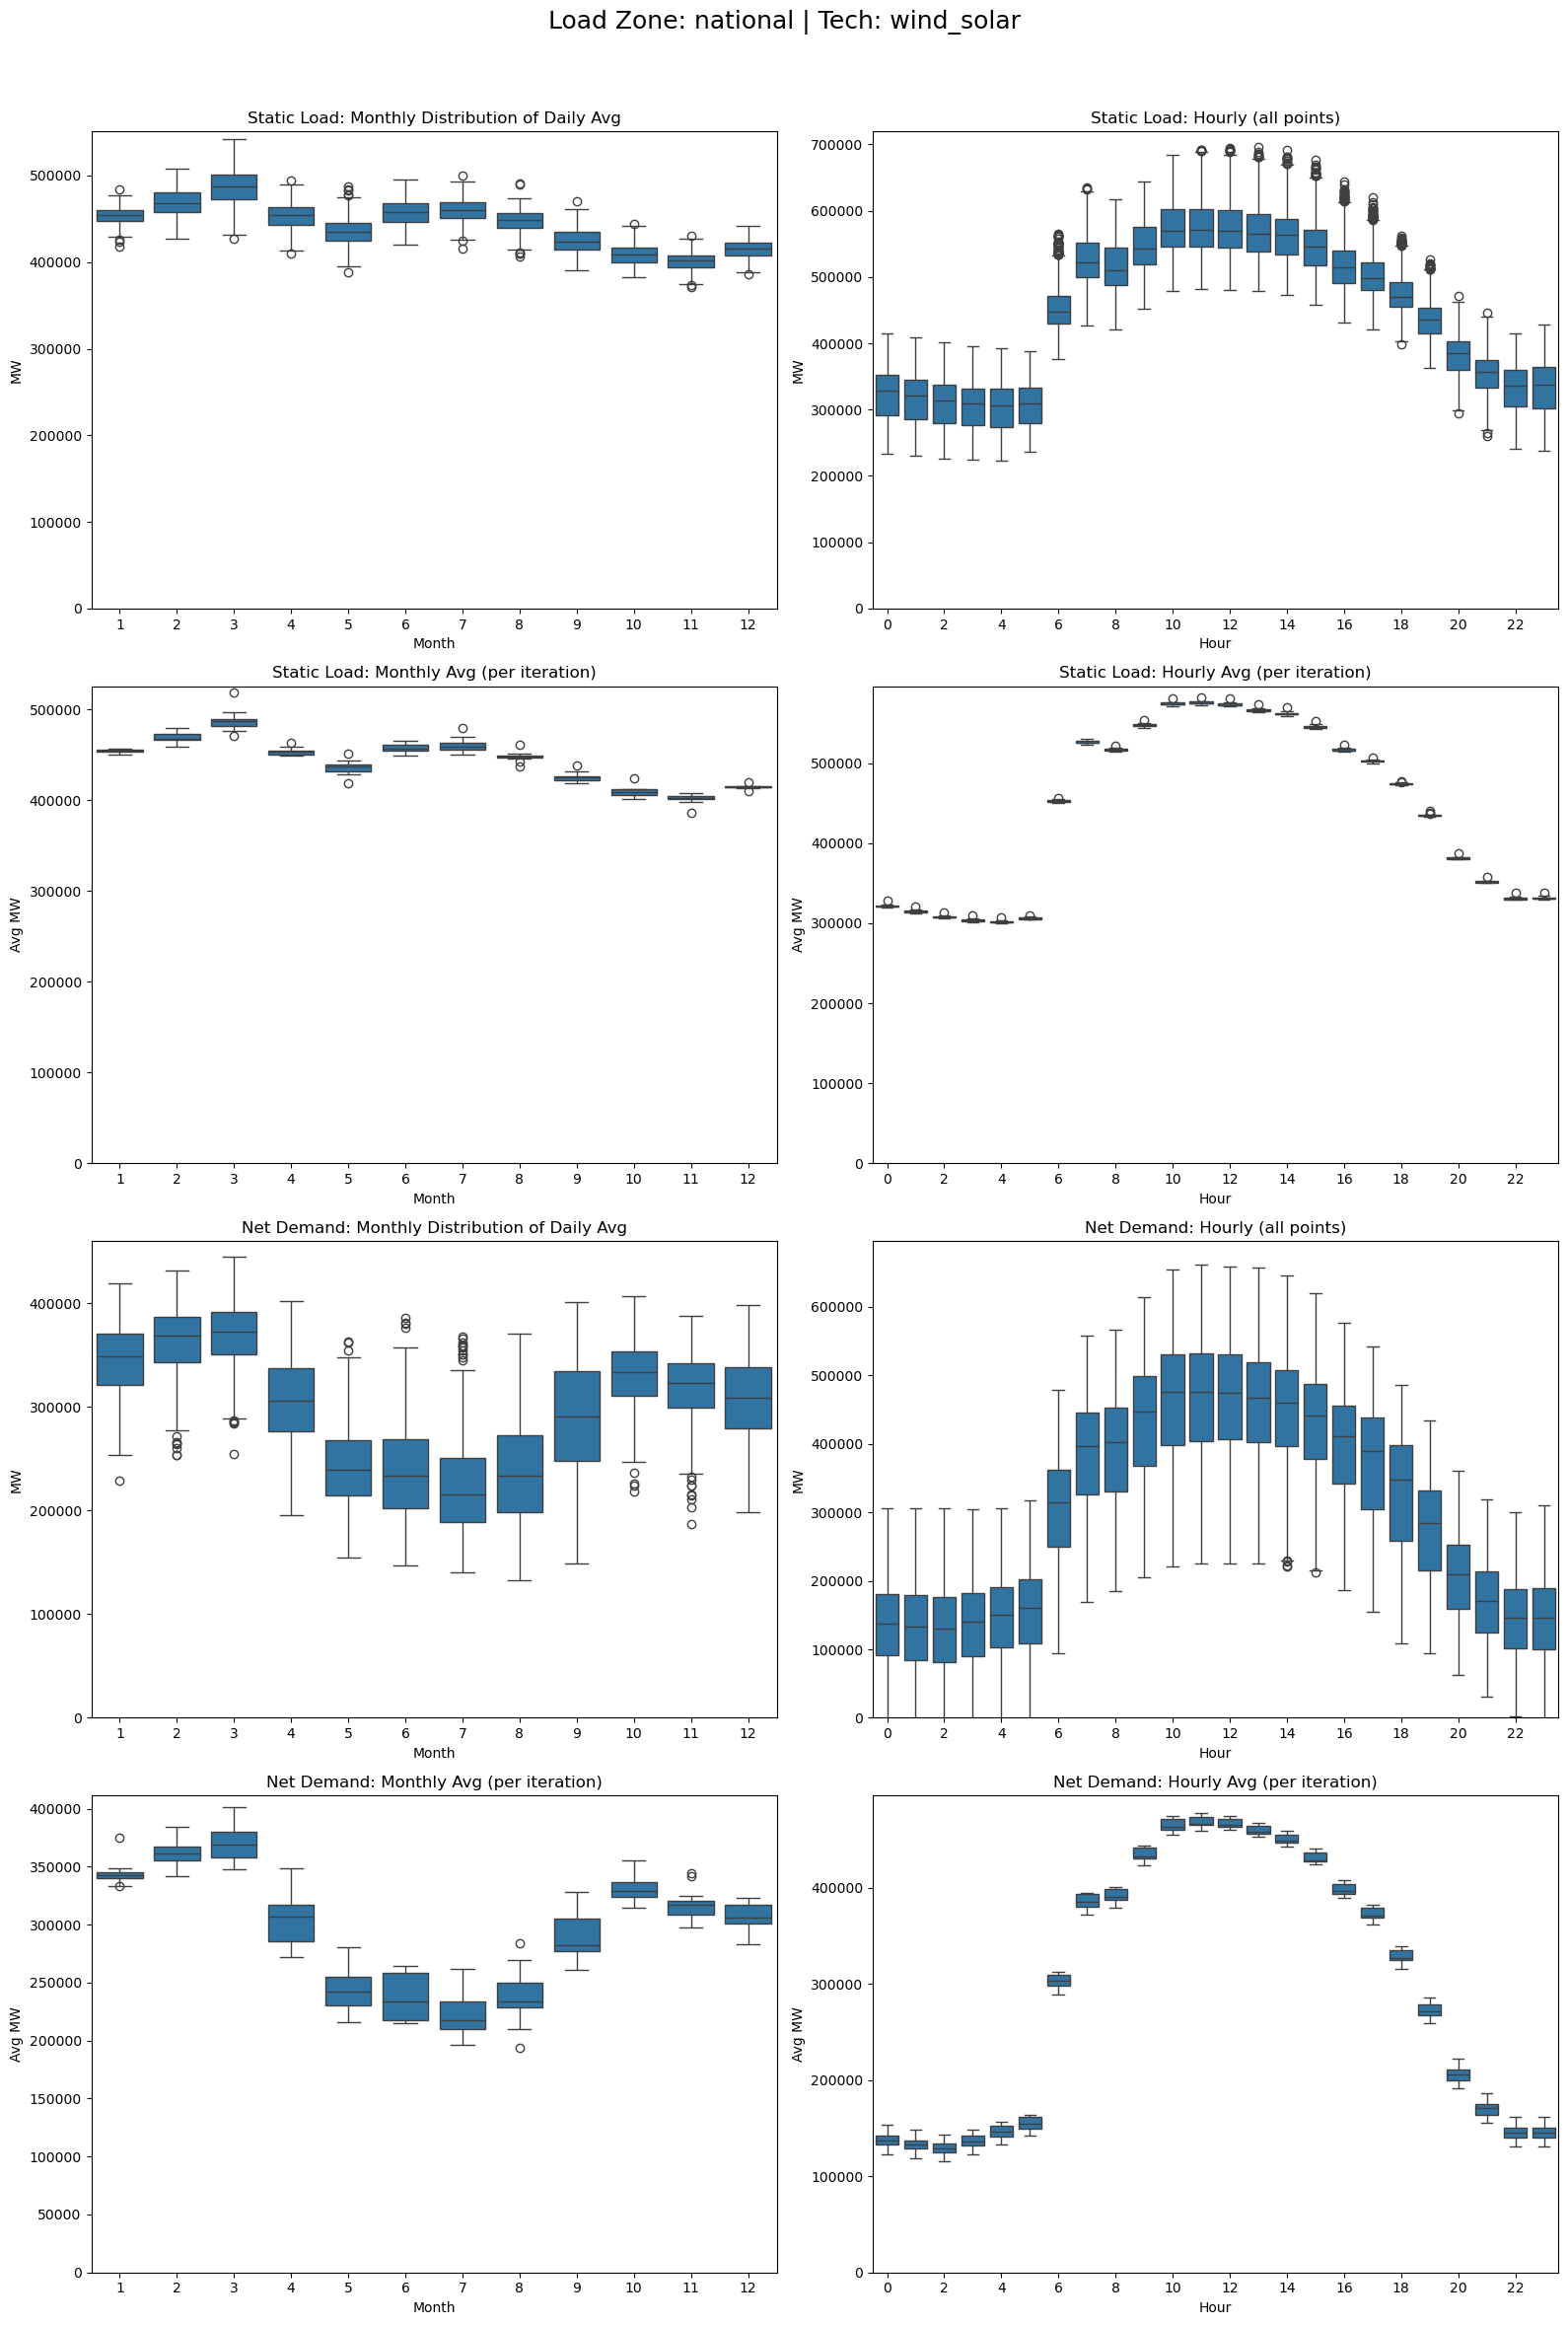

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- 1) Prepare and augment your DataFrame ---
plot_df = merged_df.copy()
plot_df['timestamp'] = pd.to_datetime(plot_df['timestamp'])
plot_df['date']      = plot_df['timestamp'].dt.date
plot_df['month']     = plot_df['timestamp'].dt.month
plot_df['hour']      = plot_df['timestamp'].dt.hour

# --- 2) Compute daily averages for static load & net demand ---
daily_avg_static = (
    plot_df
    .groupby(['weather_iteration','date'], as_index=False)['static_load_mw']
    .mean()
)
daily_avg_static['month'] = pd.to_datetime(daily_avg_static['date']).dt.month

daily_avg_net = (
    plot_df
    .groupby(['weather_iteration','date'], as_index=False)['net_demand']
    .mean()
)
daily_avg_net['month'] = pd.to_datetime(daily_avg_net['date']).dt.month

# --- 3) Compute per‐iteration/month & per‐iteration/hour averages ---
m_avg_static = plot_df.groupby(['weather_iteration','month'], as_index=False)['static_load_mw'].mean()
h_avg_static = plot_df.groupby(['weather_iteration','hour'],  as_index=False)['static_load_mw'].mean()
m_avg_net    = plot_df.groupby(['weather_iteration','month'], as_index=False)['net_demand'].mean()
h_avg_net    = plot_df.groupby(['weather_iteration','hour'],  as_index=False)['net_demand'].mean()

# --- 4) Compute total‐demand time series, then daily totals ---
timepoint_total_df = (
    plot_df
    .groupby(['weather_iteration','timestamp'], as_index=False)['static_load_mw']
    .sum()
)
timepoint_total_df['date'] = timepoint_total_df['timestamp'].dt.date   # **<-- add this**  
timepoint_total_df['hour'] = timepoint_total_df['timestamp'].dt.hour

daily_total_df = (
    timepoint_total_df
    .groupby(['weather_iteration','date'], as_index=False)['static_load_mw']
    .sum()
)
daily_total_df['month'] = pd.to_datetime(daily_total_df['date']).dt.month

# --- 5) Build your 4×2 grid of boxplots ---
zones = plot_df['load_zone'].unique()
techs = plot_df['technology'].unique()
suptitle = (
    f"Load Zone: {zones[0] if len(zones)==1 else 'Multiple Zones'} | "
    f"Tech: {', '.join(techs)}"
)

fig, axes = plt.subplots(4, 2, figsize=(16, 24))
fig.suptitle(suptitle, y=0.98, fontsize=18)

# Row 0: Static Load — Monthly (daily-avg) & Hourly (raw)
sns.boxplot(data=daily_avg_static, x='month', y='static_load_mw', ax=axes[0,0])
axes[0,0].set(title='Static Load: Monthly Distribution of Daily Avg', xlabel='Month', ylabel='MW')
axes[0,0].set_ylim(bottom=0)

sns.boxplot(data=plot_df, x='hour', y='static_load_mw', ax=axes[0,1])
axes[0,1].set(title='Static Load: Hourly (all points)', xlabel='Hour', ylabel='MW')
axes[0,1].set_xticks(range(0,24,2))
axes[0,1].set_ylim(bottom=0)

# Row 1: Static Load — Monthly Avg & Hourly Avg per iteration
sns.boxplot(data=m_avg_static, x='month', y='static_load_mw', ax=axes[1,0])
axes[1,0].set(title='Static Load: Monthly Avg (per iteration)', xlabel='Month', ylabel='Avg MW')
axes[1,0].set_ylim(bottom=0)

sns.boxplot(data=h_avg_static, x='hour', y='static_load_mw', ax=axes[1,1])
axes[1,1].set(title='Static Load: Hourly Avg (per iteration)', xlabel='Hour', ylabel='Avg MW')
axes[1,1].set_xticks(range(0,24,2))
axes[1,1].set_ylim(bottom=0)

# Row 2: Net Demand — Monthly (daily-avg) & Hourly (raw)
sns.boxplot(data=daily_avg_net, x='month', y='net_demand', ax=axes[2,0])
axes[2,0].set(title='Net Demand: Monthly Distribution of Daily Avg', xlabel='Month', ylabel='MW')
axes[2,0].set_ylim(bottom=0)

sns.boxplot(data=plot_df, x='hour', y='net_demand', ax=axes[2,1])
axes[2,1].set(title='Net Demand: Hourly (all points)', xlabel='Hour', ylabel='MW')
axes[2,1].set_xticks(range(0,24,2))
axes[2,1].set_ylim(bottom=0)

# Row 3: Net Demand — Monthly Avg & Hourly Avg per iteration
sns.boxplot(data=m_avg_net, x='month', y='net_demand', ax=axes[3,0])
axes[3,0].set(title='Net Demand: Monthly Avg (per iteration)', xlabel='Month', ylabel='Avg MW')
axes[3,0].set_ylim(bottom=0)

sns.boxplot(data=h_avg_net, x='hour', y='net_demand', ax=axes[3,1])
axes[3,1].set(title='Net Demand: Hourly Avg (per iteration)', xlabel='Hour', ylabel='Avg MW')
axes[3,1].set_xticks(range(0,24,2))
axes[3,1].set_ylim(bottom=0)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
